# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Student Performance Study Habits Dataset](https://www.kaggle.com/datasets/harshadapatil31/student-performance-and-study-habits-dataset)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

/kaggle/input/datasets/harshadapatil31/student-performance-and-study-habits-dataset/student_performance_dataset.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('student_performance_dataset.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


## last Five row

In [4]:
df.tail()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
995,996,Male,2.8,75.4,8.2,Masters,Yes,Yes,No,60.5,70.7,C
996,997,Male,6.7,88.4,7.1,NaN,No,Yes,No,82.2,99.5,A
997,998,Female,2.6,84.5,8.0,High School,Yes,Yes,Yes,65.2,79.2,C
998,999,Female,4.6,85.3,8.1,High School,No,No,Yes,52.2,82.2,B
999,1000,Male,3.9,77.4,6.1,Masters,Yes,No,No,45.4,70.4,C


## Shape of our dataset

In [5]:
df.shape

(1000, 12)

## List out all columns

In [6]:
df.columns

Index(['student_id', 'gender', 'study_time_hours', 'attendance_percent',
       'sleep_hours', 'parental_education', 'internet_access',
       'extracurricular_activities', 'part_time_job', 'previous_grade',
       'final_exam_score', 'final_grade'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

student_id                      int64
gender                         object
study_time_hours              float64
attendance_percent            float64
sleep_hours                   float64
parental_education             object
internet_access                object
extracurricular_activities     object
part_time_job                  object
previous_grade                float64
final_exam_score              float64
final_grade                    object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    object 
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   object 
 8   part_time_job               1000 non-null   object 
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 93.9+ KB


## Check Null Value

In [9]:
df.isnull().sum()

student_id                      0
gender                          0
study_time_hours                0
attendance_percent              0
sleep_hours                     0
parental_education            102
internet_access                 0
extracurricular_activities      0
part_time_job                   0
previous_grade                  0
final_exam_score                0
final_grade                     0
dtype: int64

## Drop Null Features

In [10]:
df.drop(columns=['parental_education'], inplace=True)

## Check Dupicate Value

In [11]:
df.duplicated().sum()

np.int64(0)

## Summary

In [12]:
df.describe()

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,3.570700,85.092300,6.799500,69.740900,83.543500
std,288.819436,1.478559,9.270685,1.203527,12.613425,10.341333
min,1.000000,0.500000,54.800000,3.200000,31.300000,46.800000
25%,250.750000,2.600000,78.800000,5.900000,61.000000,76.075000
50%,500.500000,3.600000,85.200000,6.800000,69.600000,83.800000
75%,750.250000,4.500000,91.900000,7.600000,78.400000,91.525000
max,1000.000000,8.100000,100.000000,10.000000,100.000000,100.000000


# EDA

In [13]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

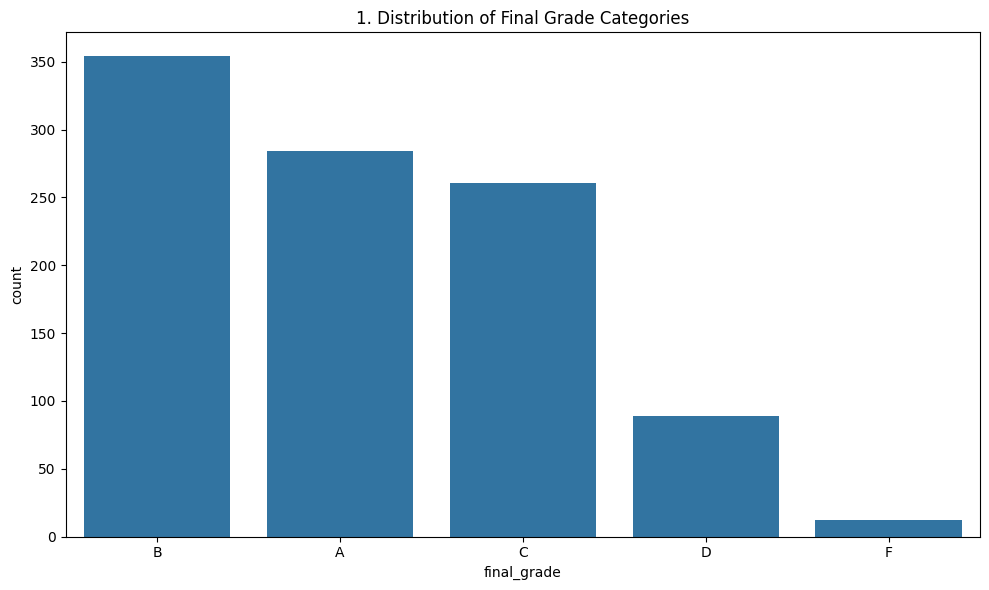

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='final_grade', order=df['final_grade'].value_counts().index)
plt.title(f'{plot_no}. Distribution of Final Grade Categories')
show_fig()
plot_no += 1

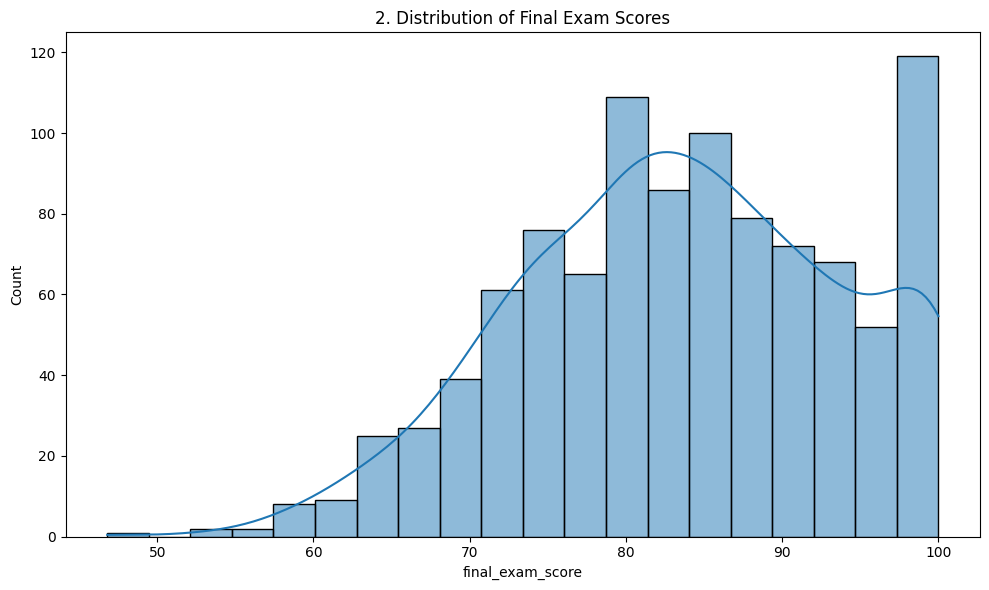

In [15]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='final_exam_score', bins=20, kde=True)
plt.title(f'{plot_no}. Distribution of Final Exam Scores')
show_fig()
plot_no += 1

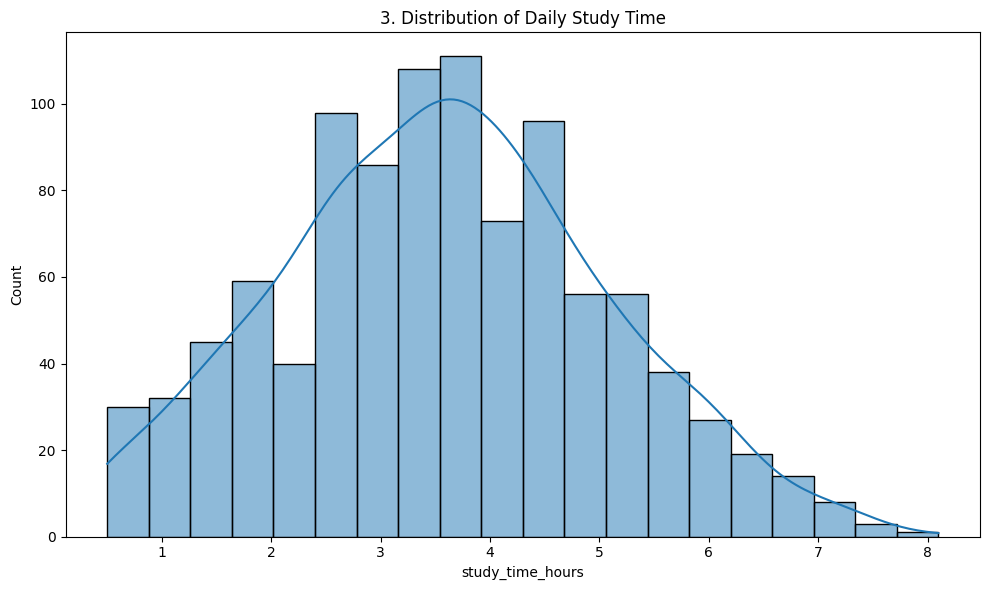

In [16]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='study_time_hours', bins=20, kde=True)
plt.title(f'{plot_no}. Distribution of Daily Study Time')
show_fig()
plot_no += 1

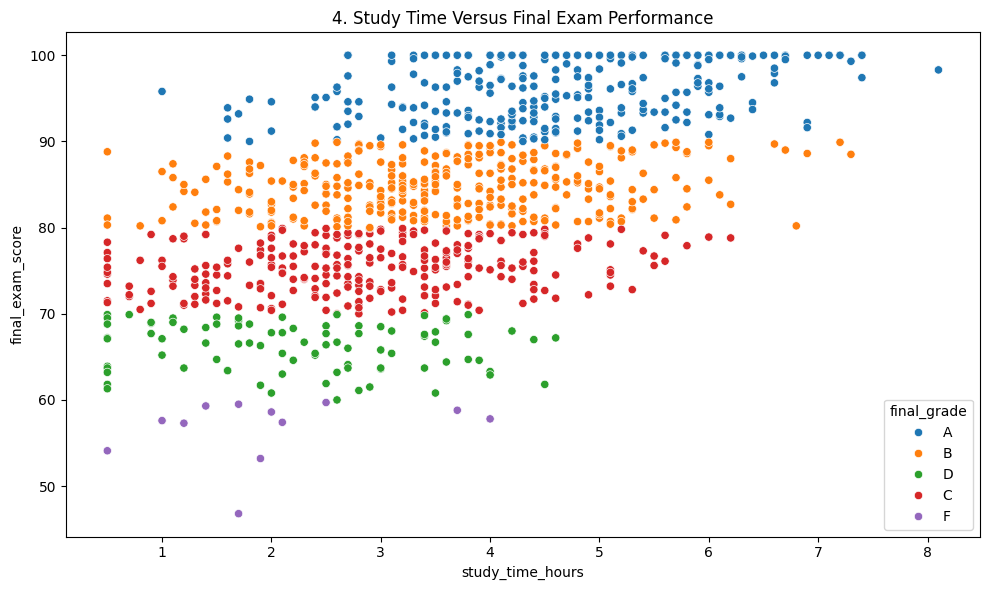

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='study_time_hours', y='final_exam_score', hue='final_grade')
plt.title(f'{plot_no}. Study Time Versus Final Exam Performance')
show_fig()
plot_no += 1

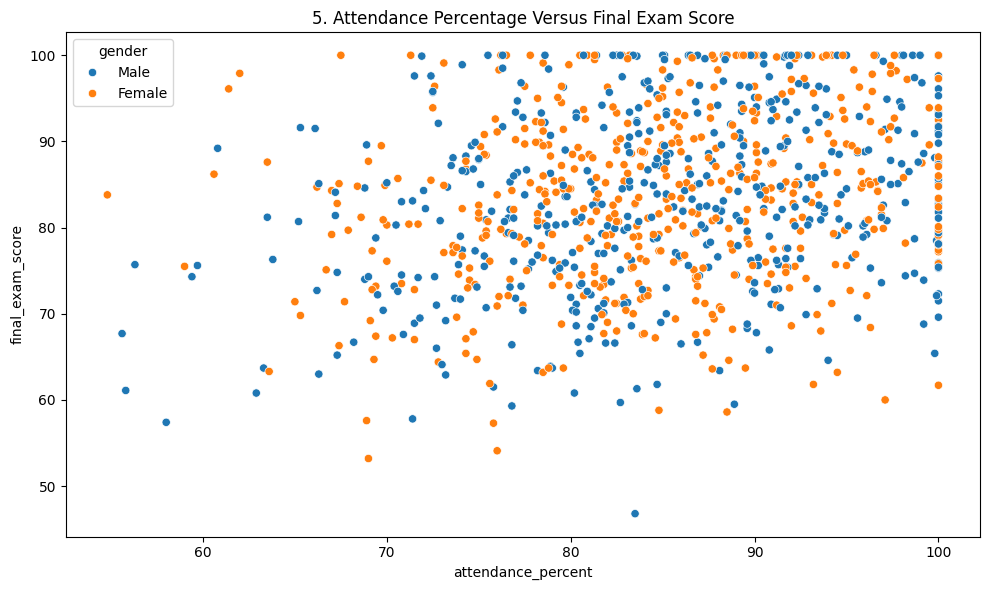

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='attendance_percent', y='final_exam_score', hue='gender')
plt.title(f'{plot_no}. Attendance Percentage Versus Final Exam Score')
show_fig()
plot_no += 1

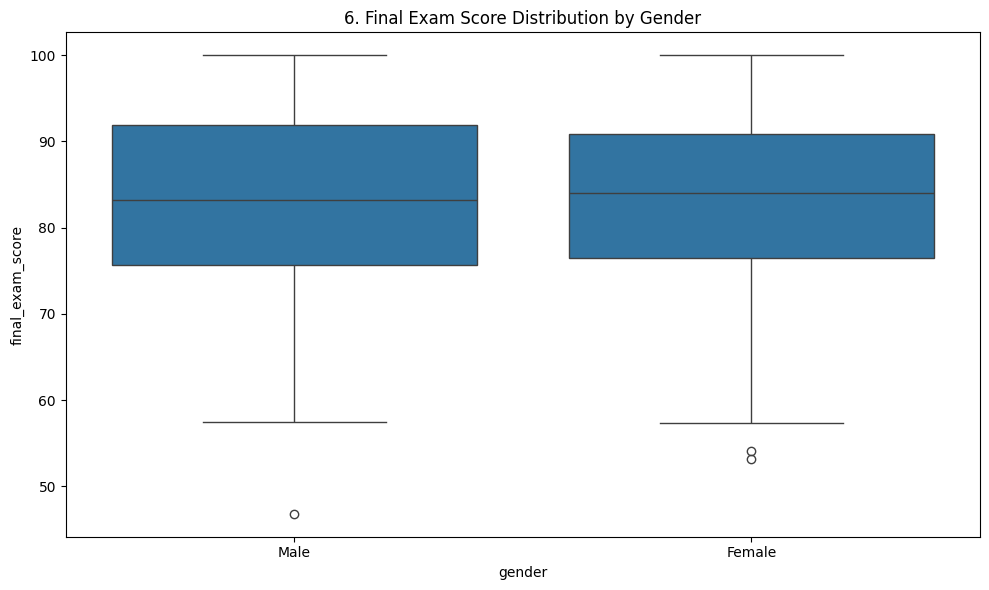

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='gender', y='final_exam_score')
plt.title(f'{plot_no}. Final Exam Score Distribution by Gender')
show_fig()
plot_no += 1

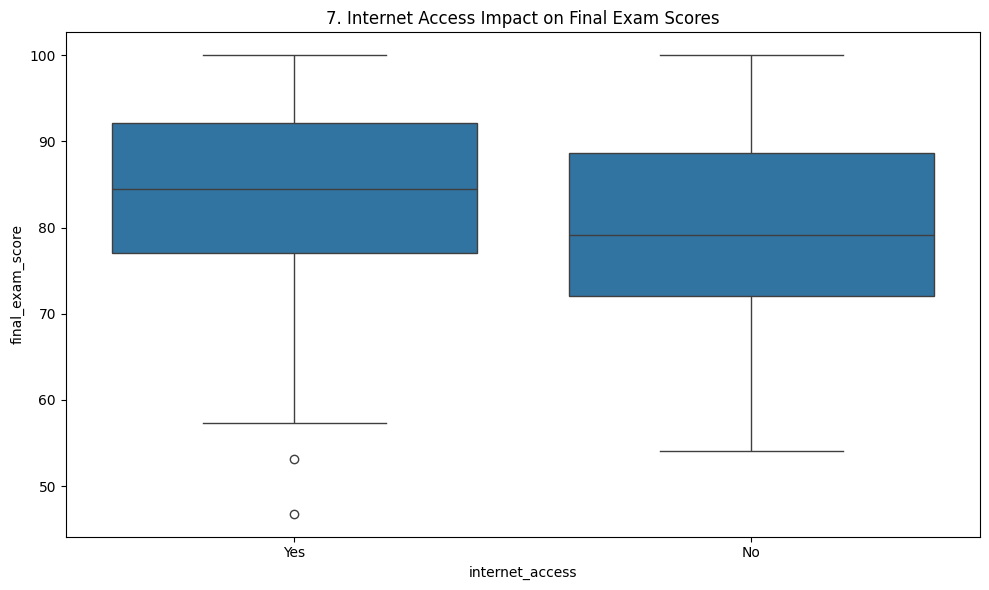

In [20]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='internet_access', y='final_exam_score')
plt.title(f'{plot_no}. Internet Access Impact on Final Exam Scores')
show_fig()
plot_no += 1

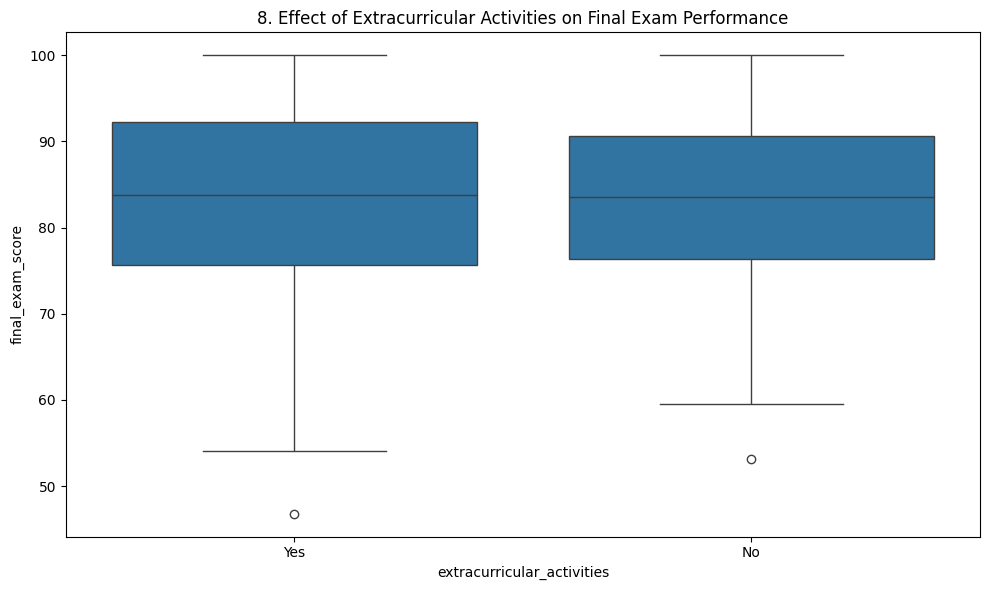

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='extracurricular_activities', y='final_exam_score')
plt.title(f'{plot_no}. Effect of Extracurricular Activities on Final Exam Performance')
show_fig()
plot_no += 1

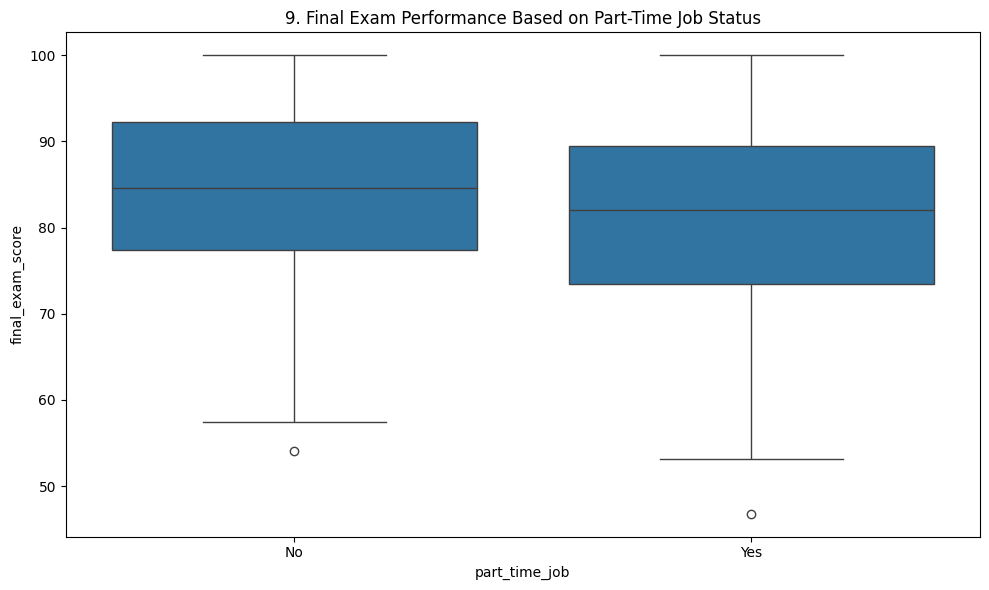

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='part_time_job', y='final_exam_score')
plt.title(f'{plot_no}. Final Exam Performance Based on Part-Time Job Status')
show_fig()
plot_no += 1

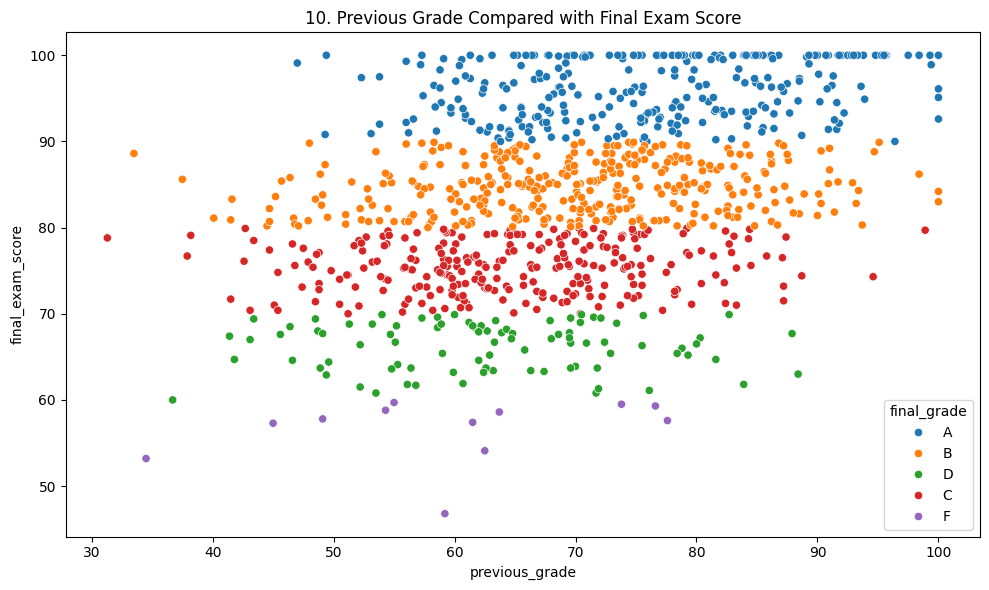

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='previous_grade', y='final_exam_score', hue='final_grade')
plt.title(f'{plot_no}. Previous Grade Compared with Final Exam Score')
show_fig()
plot_no += 1

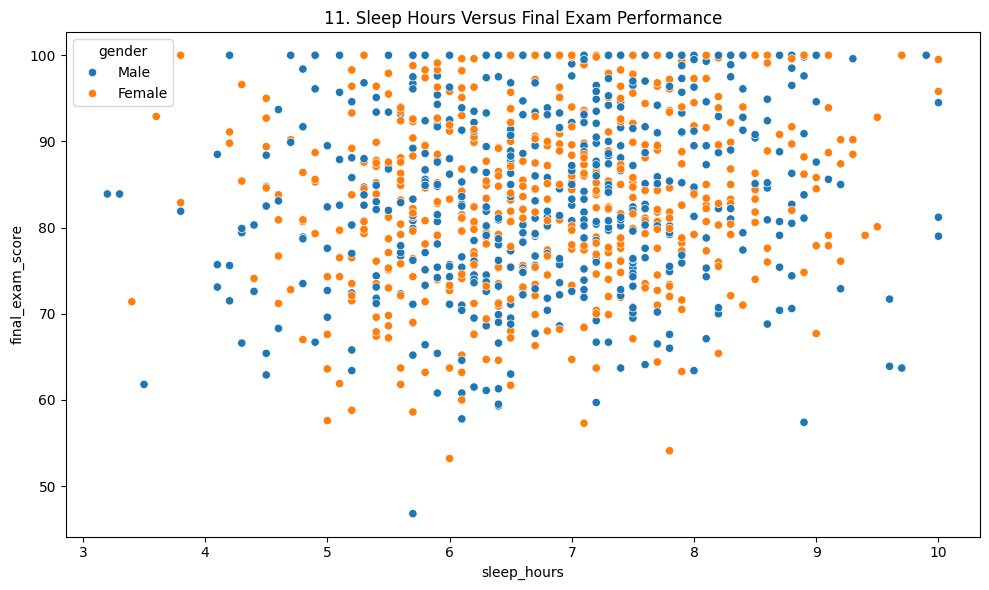

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='sleep_hours', y='final_exam_score', hue='gender')
plt.title(f'{plot_no}. Sleep Hours Versus Final Exam Performance')
show_fig()
plot_no += 1

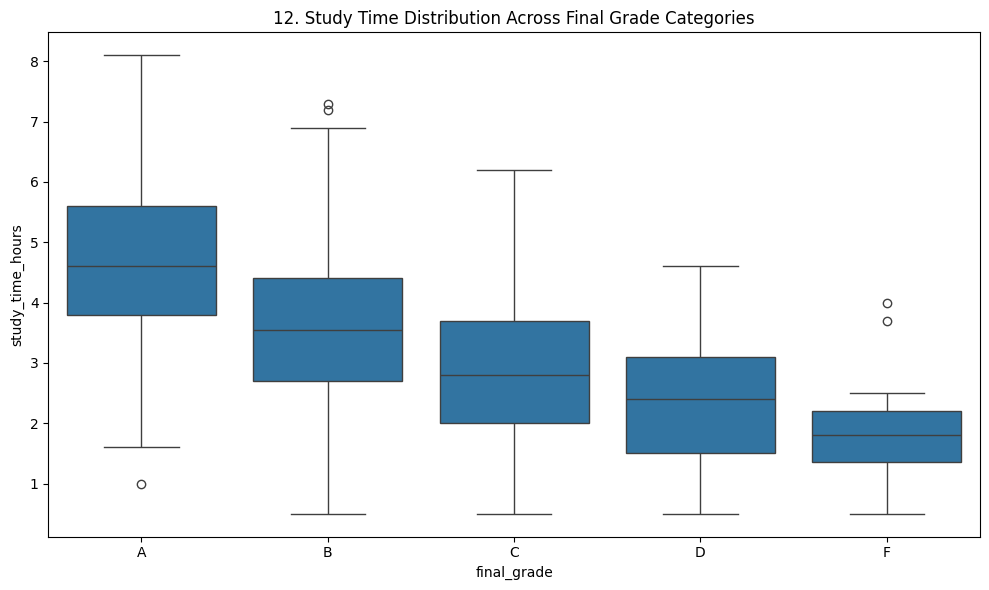

In [25]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='final_grade', y='study_time_hours', order=sorted(df['final_grade'].unique()))
plt.title(f'{plot_no}. Study Time Distribution Across Final Grade Categories')
show_fig()
plot_no += 1

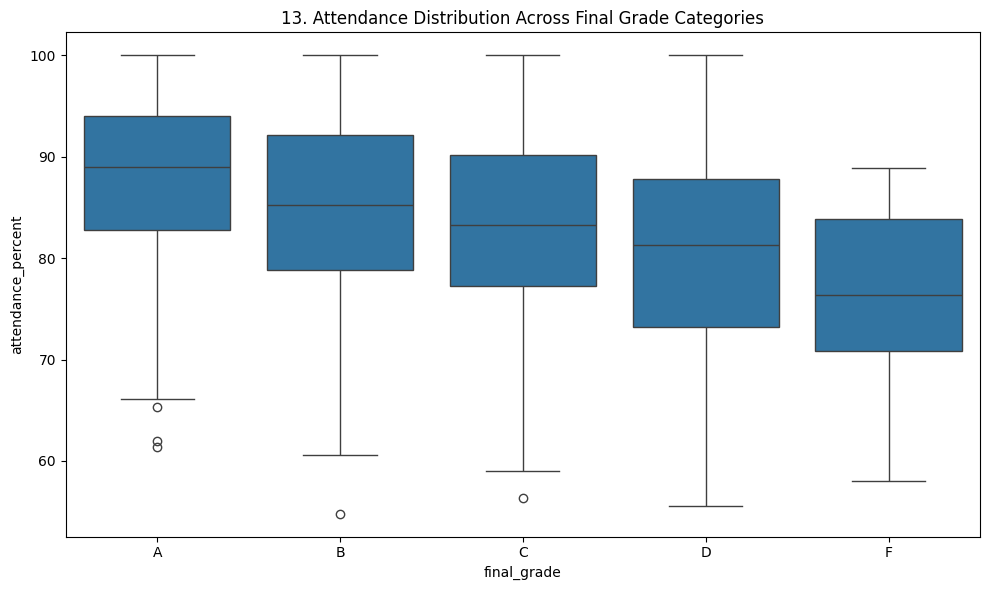

In [26]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='final_grade', y='attendance_percent', order=sorted(df['final_grade'].unique()))
plt.title(f'{plot_no}. Attendance Distribution Across Final Grade Categories')
show_fig()
plot_no += 1

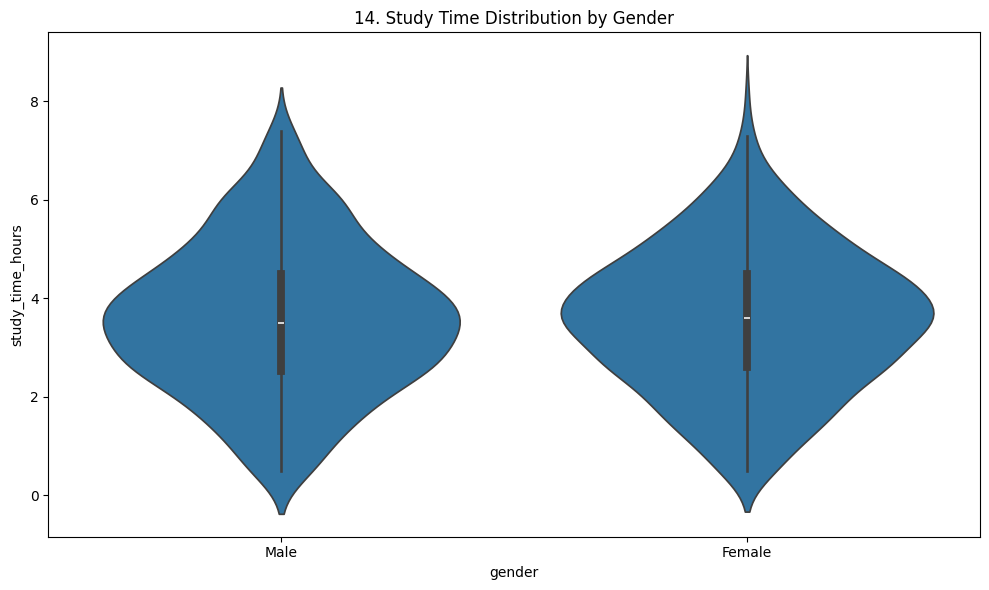

In [27]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='gender', y='study_time_hours')
plt.title(f'{plot_no}. Study Time Distribution by Gender')
show_fig()
plot_no += 1

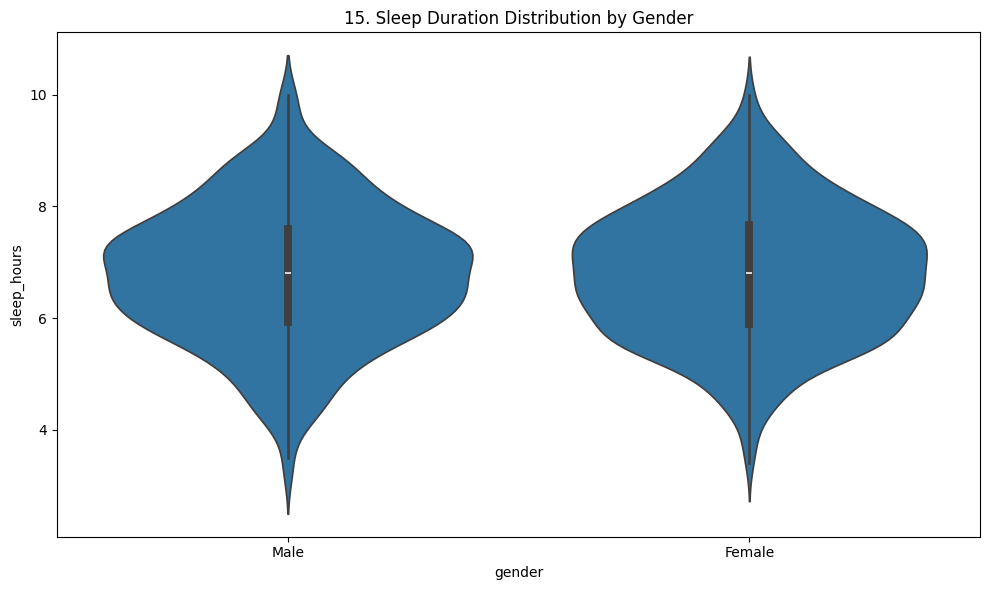

In [28]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='gender', y='sleep_hours')
plt.title(f'{plot_no}. Sleep Duration Distribution by Gender')
show_fig()
plot_no += 1

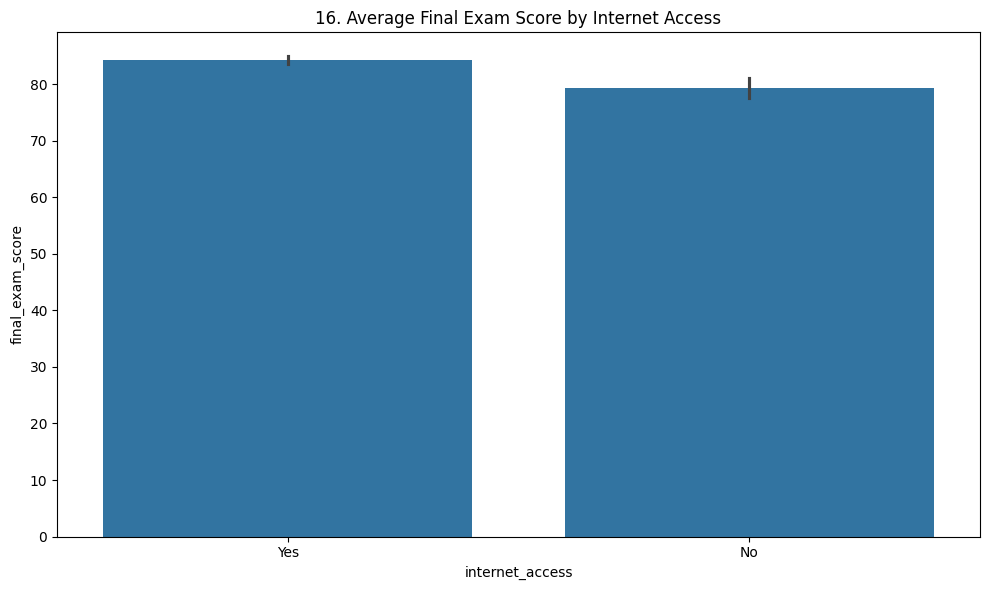

In [29]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='internet_access', y='final_exam_score', estimator='mean')
plt.title(f'{plot_no}. Average Final Exam Score by Internet Access')
show_fig()
plot_no += 1

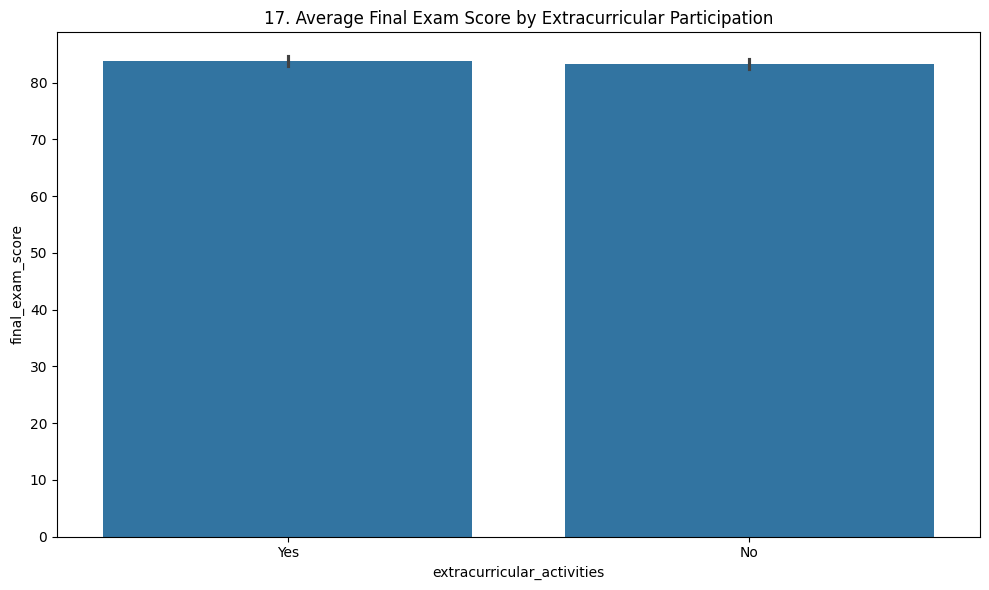

In [30]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='extracurricular_activities', y='final_exam_score', estimator='mean')
plt.title(f'{plot_no}. Average Final Exam Score by Extracurricular Participation')
show_fig()
plot_no += 1

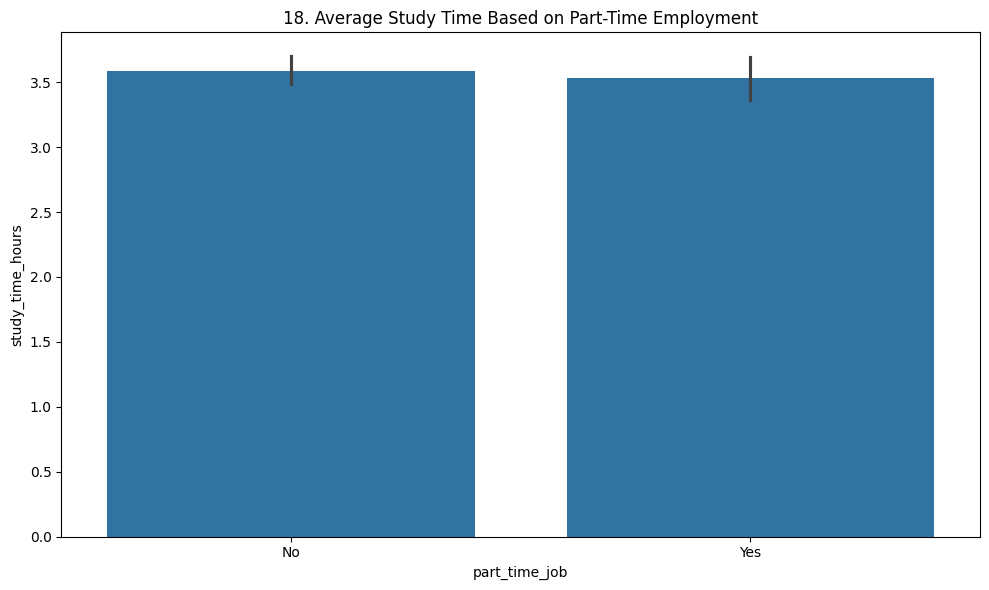

In [31]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='part_time_job', y='study_time_hours', estimator='mean')
plt.title(f'{plot_no}. Average Study Time Based on Part-Time Employment')
show_fig()
plot_no += 1

<Figure size 1000x600 with 0 Axes>

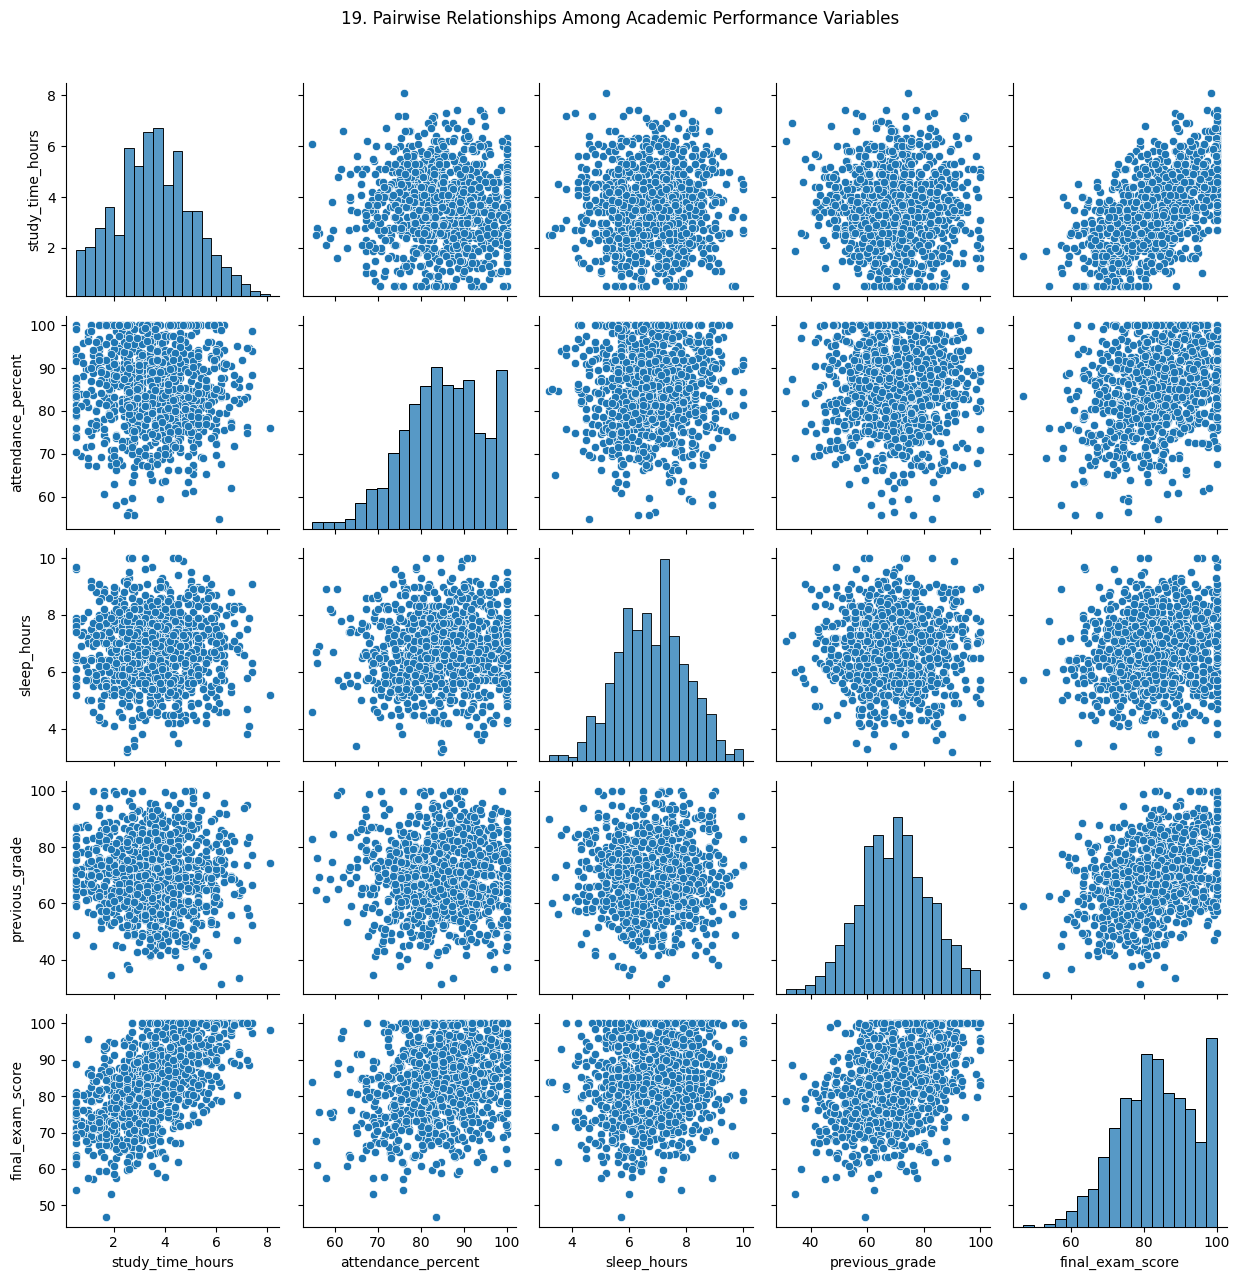

In [32]:
fig = plt.figure(figsize=(10,6))
sns.pairplot(df[['study_time_hours','attendance_percent','sleep_hours','previous_grade','final_exam_score']])
plt.suptitle(f'{plot_no}. Pairwise Relationships Among Academic Performance Variables', y=1.02)
show_fig()
plot_no += 1

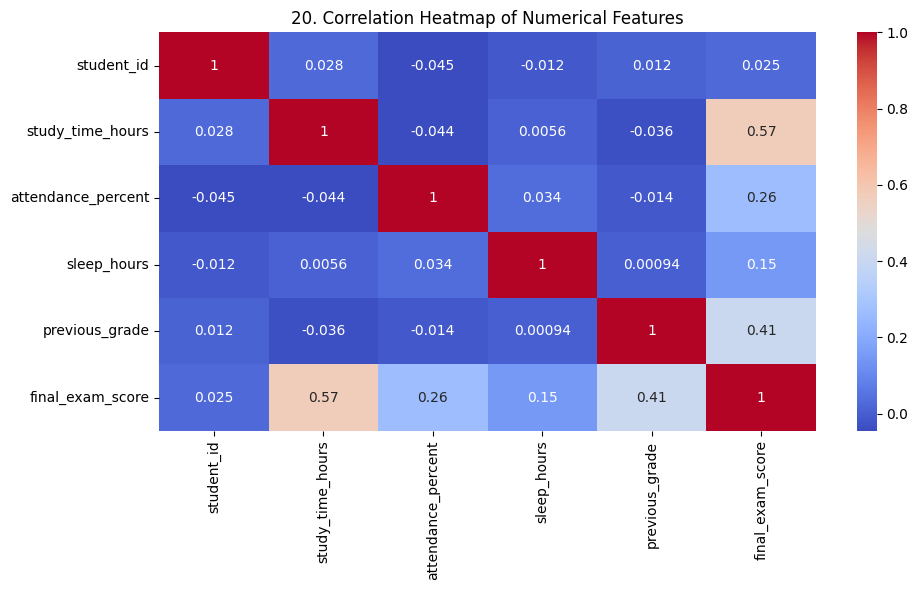

In [33]:
corr = df.select_dtypes(include='number').corr()

fig = plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features')
show_fig()
plot_no += 1

# Model Training

## Create Features and Target

In [34]:
X = df.drop(columns=['student_id', 'final_grade'])
y = df['final_grade']

## Separate Numerical and Categorical Columns

In [35]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

## Create Preprocessing Pipeline

In [36]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

## Split Dataset

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Create Model Pipeline

In [38]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', C=2, gamma='scale'))
])

## Train Model

In [39]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['study_time_hours', 'attendance_percent', 'sleep_hours',
       'previous_grade', 'final_exam_score'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'internet_access', 'extracurricular_activities',
       'part_time_job'],
      dtype='object'))])),
                ('classifier', SVC(C=2))])

## Predict

In [40]:
y_pred = model.predict(X_test)

## Print Accuracy

In [41]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score : {accuracy:.2%}\n")

Accuracy Score : 90.50%



## Plot Confusion Matrix

              precision    recall  f1-score   support

           A       0.96      0.95      0.96        57
           B       0.87      0.92      0.89        71
           C       0.90      0.87      0.88        52
           D       0.89      0.94      0.92        18
           F       0.00      0.00      0.00         2

    accuracy                           0.91       200
   macro avg       0.73      0.73      0.73       200
weighted avg       0.90      0.91      0.90       200



<Figure size 800x600 with 0 Axes>

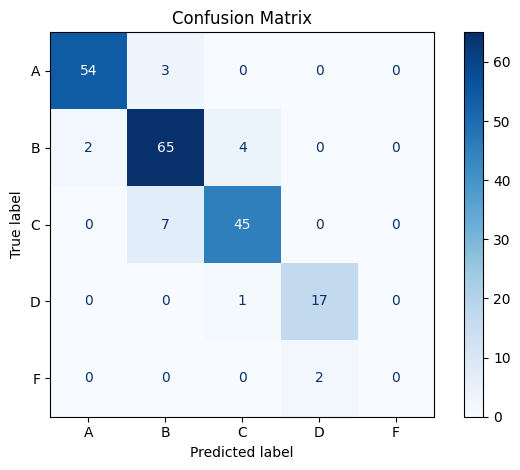

In [42]:
print(classification_report(y_test, y_pred))

fig = plt.figure(figsize=(8,6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()